Import Libraries

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ! pip install ultralytics

In [3]:
! pip install ultralytics==8.0.188 pillow==10.2.0 opencv-python==4.8.0.76 tensorflow==2.12.0 numpy==1.23.1

  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl.metadata (1.8 kB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-manylinu

In [1]:
from ultralytics import YOLO

In [ ]:
# !pip install tensorflow==2.15.1

In [2]:
import pandas as pd
import numpy as np
import cv2, os, math, pickle
from keras.models import load_model
import tensorflow as tf
import keras.backend as K

In [3]:
import matplotlib.pyplot as plt

In [4]:
tf.__version__

'2.12.0'

Load segmentation models

In [5]:
scale_model = YOLO("/content/drive/MyDrive/Sowmya /models/Sardine/v4/scale_detection_model.pt")
fish_model = YOLO("/content/drive/MyDrive/Sowmya /models/segmentation/kartik/fish.pt")

WARNING ⚠️ /content/drive/MyDrive/Sowmya /models/Sardine/v4/scale_detection_model.pt appears to require 'dill', which is not in ultralytics requirements.
AutoInstall will run now for 'dill' but this feature will be removed in the future.
Recommend fixes are to train a new model using the latest 'ultralytics' package or to run a command with an official YOLOv8 model, i.e. 'yolo predict model=yolov8n.pt'
requirements: Ultralytics requirement ['dill'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 3.1 MB/s eta 0:00:00

requirements: AutoUpdate success ✅ 4.7s, installed 1 package: ['dill']
requirements: ⚠️ Restart runtime or rerun command for updates to take effect



Load cuts and damages model

In [6]:
cuts_damages_model_path = "/content/drive/MyDrive/Sowmya /models/cut.pt"
cuts_damages_model = YOLO(cuts_damages_model_path)

In [7]:
cuts_damages_model_path = "/content/drive/MyDrive/Sowmya /models/cut-seg.pt"
cuts_damages_model = YOLO(cuts_damages_model_path)

Load size based classification model

In [8]:
size_based_model_path = "/content/drive/MyDrive/Sowmya /models/Sardine/v4/Logistic Regression.pkl"
def load_size_based_model(model_path):
    with open(model_path, 'rb') as f:
        model = pickle.load(f)
    return model
size_based_model = load_size_based_model(size_based_model_path)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.2.2 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Load softness based classification model

In [9]:
def calc_cm_vals(y_true, y_pred, class_index=None):
    pred = tf.argmax(y_pred, axis=1)
    true = tf.reshape(y_true, (-1,))

    tp = tf.reduce_sum(tf.cast(tf.logical_and(tf.equal(true, class_index),
                                              tf.equal(pred, class_index)),
                                               tf.float32))
    fp = tf.reduce_sum(tf.cast(tf.logical_and(tf.not_equal(true, class_index),
                                              tf.equal(pred, class_index)),
                                               tf.float32))
    fn = tf.reduce_sum(tf.cast(tf.logical_and(tf.equal(true, class_index),
                                             tf.not_equal(pred, class_index)),
                                              tf.float32))
    return tp, fp, fn

def recall(y_true, y_pred, class_index=1):
    tp, fp, fn = calc_cm_vals(y_true, y_pred, class_index)
    return tp / (tp + fn + K.epsilon())

def precision(y_true, y_pred, class_index=0):
    tp, fp, fn = calc_cm_vals(y_true, y_pred, class_index)
    return tp / (tp + fp + K.epsilon())

Sowmya's model

In [10]:
def load_softness_model(softness_model_path):
    custom_metrics = {'recall_1':recall, 'precision_0':precision}
    softness_model = load_model(softness_model_path,
                                custom_objects=custom_metrics)
    return softness_model

In [11]:
softness_model_path = "/content/drive/MyDrive/Sowmya /models/Sardine/v2/2011_1_densenet_single_dropout_0.2_recall_1_precision_0_accuracy_mobilenetv2_model.h5"
softness_model = load_softness_model(softness_model_path)

Kartik's model

In [12]:
def load_softness_model(softness_model_path):
    # custom_metrics = {'recall_1':recall, 'precision_0':precision}
    softness_model = load_model(softness_model_path,
                                custom_objects={})
    return softness_model

In [13]:
softness_model_path = "/content/drive/MyDrive/Sowmya /models/Sardine/sardine_june.h5"
softness_model = load_softness_model(softness_model_path)

In [14]:
softness_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 densenet121 (Functional)    (None, 7, 7, 1024)        7037504   
                                                                 
 global_average_pooling2d (G  (None, 1024)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 128)               131200    
                                                                 
 batch_normalization (BatchN  (None, 128)              512       
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                8

In [15]:
def yolo_results(img_path, model, conf=0.5, iou=0.7):
    results = model(img_path, conf=conf, iou=iou, verbose=False)
    return results

Cuts and damages model utils

In [16]:
def process_image2(image, size=(640, 640)): # for eye model
    h, w = image.shape[:2]
    aspect_ratio = w / h
    if aspect_ratio > 1:
        new_w = size[0]
        new_h = int(new_w / aspect_ratio)
    else:
        new_h = size[1]
        new_w = int(new_h * aspect_ratio)

    resized_image = cv2.resize(image, (new_w, new_h))

    pad_h = (size[1] - new_h) // 2
    pad_w = (size[0] - new_w) // 2
    padded_image = cv2.copyMakeBorder(
        resized_image, pad_h, pad_h, pad_w, pad_w, cv2.BORDER_CONSTANT, value=(255, 255, 255)
    )
    padded_image = cv2.resize(padded_image, (640,640))
    return np.asarray(padded_image)

def is_cut(image):
    img = image[:,:,::-1]
    res = cuts_damages_model.predict(img, conf=0.5)
    if len(res[0].boxes.xyxy) == 0:
        return False
    else:
        return True

# old

In [17]:
def cuts_damages(seg_img_list):
    for i in range(len(seg_img_list)):
        seg_img_list = seg_img_list[:,:,::-1]
        results = yolo_results(seg_img_list, cuts_damages_model, conf=0.5, iou=0.7)
        cuts_detected = len(results[0].boxes.cls)
        if cuts_detected == 0:
            return None
        else:
            return True

# new

In [18]:
def cuts_damages(seg_img_list):
    for i in range(len(seg_img_list)):
        image = process_image2(seg_img_list[i])
        image = image[:,:,::-1]
        results = yolo_results(image, cuts_damages_model, conf=0.5, iou=0.7)
        cuts_detected = len(results[0].boxes.cls)
        if cuts_detected == 0:
            return None
        else:
            return True

Size based model utils

In [19]:
def circumference_area(img):
    # Load the segmented fish image
    # image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    image = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Threshold the image to create a binary mask
    _, binary_mask = cv2.threshold(image, 1, 255, cv2.THRESH_BINARY)

    # Find contours in the binary mask
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Ensure at least one contour was found
    if len(contours) > 0:
        # Get the largest contour (presumably the fish)
        largest_contour = max(contours, key=cv2.contourArea)

        # Calculate the circumference of the contour
        circumference = cv2.arcLength(largest_contour, closed=True)

        # Calculate the area enclosed by the contour
        area = cv2.contourArea(largest_contour)
        return circumference, area
    else:
        return 0, 0

In [20]:
def get_object_height(results, index=0):
    hp = int(results[0].boxes.xywh[index][3])
    wp = int(results[0].boxes.xywh[index][2])
    dp = int(math.hypot(hp, wp))
    if hp<wp: (hp, wp) = (wp, hp)
    # else: hp, wp, dp = (0, 0, 0)
    return hp, wp, dp

scale_hcm = 12 for app testing images

scale_hcm = 16 for data collection images

In [21]:
def pixel_to_cm(fish_hp, fish_wp, fish_dp, scale_hp, scale_wp, scale_dp):
    try:
        scale_hcm = 13
        one_pixel_value = scale_hcm / scale_hp
        fish_hcm = int(fish_hp * one_pixel_value)
        fish_wcm = int(fish_wp * one_pixel_value)
        fish_dcm = int(fish_dp * one_pixel_value)
        scale_dcm = int(scale_dp * one_pixel_value)
        scale_wcm = int(scale_wp * one_pixel_value)
    except:
        (fish_hcm, fish_wcm, fish_dcm,
         scale_dcm, scale_wcm, one_pixel_value) = (0, 0, 0, 0, 0, 0)

    return (fish_hcm, fish_wcm, fish_dcm, scale_dcm,
            scale_wcm, one_pixel_value)

In [22]:
def single_img_data(fish_hp, fish_wp, fish_dp,
                    scale_hp, scale_wp, scale_dp,
                    fish_img_list):
    (fish_hcm, fish_wcm, fish_dcm, scale_dcm, scale_wcm,
     one_pixel_value) = pixel_to_cm(fish_hp, fish_wp, fish_dp,
                                  scale_hp, scale_wp, scale_dp)
    data = []
    for fish_img in fish_img_list:
        circumference, area = circumference_area(fish_img)
        if one_pixel_value != 0:
            circumference = int(circumference * one_pixel_value)
            area = int(area * one_pixel_value * one_pixel_value)

        data.append((fish_hcm, fish_wcm, fish_dcm,
                      scale_dcm, scale_wcm, one_pixel_value,
                      circumference, area))
    # Create a DataFrame
    df = pd.DataFrame(data, columns=['FishHeight', 'FishWidth',
                  'FishDiagonal', 'ScaleDiagonal', 'ScaleWidth',
                  'OnePixelValue', 'Circumference', 'Area'])
    return df

In [23]:
def pred_single_img(test_df, model):
    label_map = {0: 'Bad', 1: 'Good'}
    probabilities = []
    for index, row in test_df.iterrows():
        Height = row['FishHeight']
        Width = row['FishWidth']
        diagonal = row['FishDiagonal']
        Circumference = row['Circumference']
        Area = row['Area']
        X_test = [[Height, Width, diagonal, Circumference, Area]]
        # pred = model.predict(X_test)
        # Get probability estimates for the predicted labels
        y_proba = model.predict_proba(X_test)
        probabilities.append(y_proba)

    # Set your chosen threshold
    threshold = 0.8
    # threshold = 0.7
    print(probabilities)
    # Adjust predictions based on the threshold
    predictions = np.ones(len(probabilities))
    for i in range(len(probabilities)):
        if probabilities[i][0][0] >= threshold:
            predictions[i] = 0

    return (label_map[int(predictions[0])])

softness model utils

In [24]:
def preprocess_img(image, target_size):
    if image is not None:
        height, width, channels = image.shape
        if width<height :
            image = cv2.rotate(image, cv2.ROTATE_90_CLOCKWISE)
    preprocessed_image = cv2.resize(image, target_size)
    converted_image = cv2.cvtColor(preprocessed_image, cv2.COLOR_BGR2RGB)
    reshaped_image = converted_image.reshape(1, *converted_image.shape)
    image = reshaped_image.astype(np.float32)
    image = image / 255.0
    return image

def softness_model_predict(img, model):
    label_map = {'Bad': 0, 'Good': 1}
    target_size = (280, 180)
    preprocessed_img = preprocess_img(img[0], target_size)
    prediction = model.predict(preprocessed_img, verbose=0)
    prediction = np.array([np.argmax(pred) for pred in prediction])
    reverse_label_map = {idx: img_type for img_type, idx in label_map.items()}
    predicted_class = reverse_label_map[prediction[0]]
    return predicted_class

Kartik softness model utils

In [25]:
from tensorflow.keras.applications.densenet import preprocess_input

In [26]:
def preprocess_img(image, target_size): #old
    if image is not None:
        resized_image = cv2.resize(image, target_size)
        # converted_image = cv2.cvtColor(preprocessed_image, cv2.COLOR_BGR2RGB)
        reshaped_image = resized_image.reshape(1, *resized_image.shape)
        # image = reshaped_image.astype(np.float32)
        # image = image / 255.0
        image = preprocess_input(reshaped_image)
        return image

def preprocess_img(image, target_size): #new
    if image is not None:
        resized_image = cv2.resize(image, target_size)
        # converted_image = cv2.cvtColor(preprocessed_image, cv2.COLOR_BGR2RGB)
        # image = reshaped_image.astype(np.float32)
        # image = image / 255.0
        image = preprocess_input(resized_image)
        image = image.reshape(1, *image.shape)
        return image

def softness_model_predict(img, model):
    label_map = {'Bad': 0, 'Good': 1}
    # label_map = {'Bad': 1, 'Good': 0}
    target_size = (224, 224)
    preprocessed_img = preprocess_img(img[0], target_size)
    prediction = model.predict(preprocessed_img, verbose=0)
    prediction = np.array(prediction)
    threshold = 0.5
    prediction = (prediction >= threshold).astype(int)
    prediction = prediction[0]
    reverse_label_map = {idx: img_type for img_type, idx in label_map.items()}
    predicted_class = reverse_label_map[prediction[0]]
    return predicted_class

Drawing bboxes, masks and labels

In [27]:
def add_text(img, text):
    font = cv2.FONT_HERSHEY_SIMPLEX
    fontScale = 1
    color = (0, 0, 0)
    thickness = 2

    # Using cv2.putText() method
    out_img = cv2.putText(img, text, (10, 30), font, fontScale, color, thickness, cv2.LINE_AA)
    return out_img

In [28]:
def get_segmented_img(pred, white_background=False, index=0):
    img_shape = pred.orig_shape
    img = pred.orig_img.copy()
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    height, width = img_shape[0], img_shape[1]
    masks = pred.masks.xy
    seg_img_list = []
    mask = masks[index]
    mask_points = mask.astype(int)
    binary_mask = np.zeros((height, width), dtype=np.uint8)
    cv2.fillPoly(binary_mask, [mask_points], 255)
    masked_img = cv2.bitwise_and(img, img, mask=binary_mask)
    x, y, w, h = cv2.boundingRect(mask_points)
    x1, y1, x2, y2 = (x, y, x+w, y+h)
    box = [x1, y1, x2, y2]
    segment_image = np.zeros((height, width, 3), dtype=np.uint8)
    segment_image[y:y+h, x:x+w] = masked_img[y:y+h, x:x+w]
    segment_image = segment_image[y:y+h, x:x+w]
    # white_background = False
    if white_background:
        black_mask = np.all(segment_image == [0, 0, 0], axis=-1)
        segment_image[black_mask] = [255, 255, 255]
    seg_img_list.append(segment_image)
    # return seg_img_list
    return seg_img_list, masks[index], box

In [29]:
def get_colors(pred_class):
    if pred_class == 'Bad':
        color = (0, 0, 255)
    else:
        color = (0, 255, 0)
    return color

In [30]:
def draw_annotated_boxes(img, box, color, text):
    cv2.rectangle(img, (box[0], box[1]), (box[2], box[3]),
                  color, 5)
    # Define the font and scale of the text
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 4
    font_color = (255, 255, 255)  # White color
    font_thickness = 15
    text_position = (box[0], box[1] - 10)

    # Get the size of the text to calculate the background rectangle
    (text_width, text_height), baseline = cv2.getTextSize(
                                text, font, font_scale, font_thickness)

    # Calculate the position for the background rectangle
    background_rect_start = (box[0], box[1] - text_height - 10)
    # background_rect_end = (box[0] + text_width, box[1] - baseline + 10)
    background_rect_end = (box[0] + text_width, box[1])

    # Draw the background rectangle
    cv2.rectangle(img, background_rect_start,
                  background_rect_end, color, -1)

    # Put the text on the image
    out_img = cv2.putText(img, text, text_position,
                          font, font_scale, font_color, font_thickness)
    return out_img

In [31]:
def fill_mask(img, mask, color):
    height, width = img.shape[0], img.shape[1]
    binary_mask = np.zeros((height, width), dtype=np.uint8)
    mask = mask.astype(np.int32)
    cv2.fillPoly(binary_mask, [mask], 255)
    # return binary_mask

    masked_img = cv2.bitwise_and(img, img, mask=binary_mask)
    masked_img[binary_mask == 255] = color
    transparency = 0.8
    masked_img = cv2.addWeighted(img, 1.0, masked_img, transparency, 0)
    return masked_img

In [32]:
def draw_bbox_masks_labels(img, mask, box, text, color):
    masked_img = fill_mask(img, mask, color)
    out_img = draw_annotated_boxes(masked_img, box, color, text)
    return out_img

Final Output

In [33]:
def get_result_img(results):
    obj_detected = len(results[0].boxes.cls)
    if obj_detected == 0:
        # add text 'No fish detected' over the image
        output_img = add_text(results[0].orig_img, 'No fish detected')
        return output_img
    else:
        output_img = results[0].orig_img
        for i in range(obj_detected):
            seg_img_list, mask, bbox = get_segmented_img(results[0], True, i)
            # Go to Cuts and damages model
            cuts = cuts_damages(seg_img_list)
            if (cuts==None) or (cuts == False):
                # go to scale detection model
                seg_img_list, mask, bbox = get_segmented_img(results[0], False, i)
                orig_img = results[0].orig_img
                # orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
                res = yolo_results(orig_img, scale_model)
                if len(res[0].boxes.cls) == 0:
                    # print("No scale detected")
                    pred = softness_model_predict(seg_img_list, softness_model)
                    color = get_colors(pred)
                    text = f'{pred}: Soft'
                    if pred == 'Good': text = f'{pred}'
                    print(text)
                    output_img = draw_bbox_masks_labels(output_img, mask,
                                                        bbox, text, color)

                else:
                    # print("Scale detected")
                    # scale_seg_img, m, b = get_segmented_img(res[0])
                    # get the dimensions of the scale
                    scale_hp, scale_wp, scale_dp = get_object_height(res)
                    fish_hp, fish_wp, fish_dp = get_object_height(results, i)
                    df = single_img_data(fish_hp, fish_wp, fish_dp,
                                           scale_hp, scale_wp, scale_dp,
                                           seg_img_list)
                    display(df)
                    # go to size based classification model
                    pred = pred_single_img(df, size_based_model)
                    if pred == 'Bad':
                        color = get_colors(pred)
                        text = f'{pred}: Size'
                        print(text)
                        output_img = draw_bbox_masks_labels(output_img, mask,
                                                            bbox, text, color)
                    else:
                        # go to softness model
                        pred = softness_model_predict(seg_img_list, softness_model)
                        color = get_colors(pred)
                        text = f'{pred}: Soft'
                        if pred == 'Good': text = f'{pred}'
                        print(text)
                        output_img = draw_bbox_masks_labels(output_img, mask,
                                                            bbox, text, color)
            else:
                pred = 'Bad'
                color = get_colors(pred)
                text = f'{pred}: Cuts'
                print(text)
                output_img = draw_bbox_masks_labels(output_img, mask, bbox,
                                                    text, color)
    return output_img

# test an image

In [34]:
folder = "/content/drive/MyDrive/Sowmya /New app testing data/input/2024-06-11/sardine/Bad"
img_path = os.path.join(folder, '2024-06-11_10:00:58_(13522)_sardine_input.jpeg')
results = yolo_results(img_path, fish_model, conf=0.75, iou=0.7)
output_img = get_result_img(results)
# rgb_img = cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB)
# plt.imshow(rgb_img);

Bad: Cuts


,FishHeight,FishWidth,FishDiagonal,ScaleDiagonal,ScaleWidth,OnePixelValue,Circumference,Area
0,13,3,13,13,2,0.027197,30,30


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


[array([[    0.73545,     0.26455]])]
Good
Bad: Cuts


In [ ]:
folder = "/content/drive/MyDrive/Sowmya /New app testing data/input/2024-06-11/sardine/Bad"
img_path = os.path.join(folder, '2024-06-11_10:00:58_(13522)_sardine_input.jpeg')
results = yolo_results(img_path, fish_model, conf=0.75, iou=0.7)
output_img = get_result_img(results)
# rgb_img = cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB)
# plt.imshow(rgb_img);

,FishHeight,FishWidth,FishDiagonal,ScaleDiagonal,ScaleWidth,OnePixelValue,Circumference,Area
0,12,3,12,13,2,0.027197,28,24


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


[array([[    0.98318,    0.016821]])]
Bad: Size


,FishHeight,FishWidth,FishDiagonal,ScaleDiagonal,ScaleWidth,OnePixelValue,Circumference,Area
0,13,3,13,13,2,0.027197,31,30


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


[array([[    0.79152,     0.20848]])]
Good


,FishHeight,FishWidth,FishDiagonal,ScaleDiagonal,ScaleWidth,OnePixelValue,Circumference,Area
0,13,4,13,13,2,0.027197,33,28


[array([[    0.89645,     0.10355]])]
Bad: Size


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


scale_hcm = 12 for app testing images

scale_hcm = 16 for data collection images

In [ ]:
# img_path = "/content/drive/MyDrive/Sowmya /models/Sardine/v4/20240224091224451_sardine_good.jpeg"
# img_path = "/content/drive/MyDrive/Sowmya /models/Sardine/v4/2024-04-05_09_49_01_(10557)_sardine_input.jpeg"
# img_path = "/content/drive/MyDrive/Sowmya /models/Sardine/v4/IMG_20240227_103521964.jpg"
# img_path = "/content/drive/MyDrive/Sowmya /models/Sardine/v4/20230527080427840_sardine_bad.JPEG"
img_path = "/content/drive/MyDrive/Sowmya /models/Sardine/v4/20240131105530006_sardine_bad.jpeg"
# img_path = "/content/drive/MyDrive/Sowmya /models/Sardine/v4/20240326093504580_sardine_bad.jpeg"

In [ ]:
results = yolo_results(img_path, fish_model, conf=0.75, iou=0.7)
output_img = get_result_img(results)

,FishHeight,FishWidth,FishDiagonal,ScaleDiagonal,ScaleWidth,OnePixelValue,Circumference,Area
0,14,4,15,16,1,0.007102,35,29


[array([[    0.82607,     0.17393]])]
Bad: Size


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


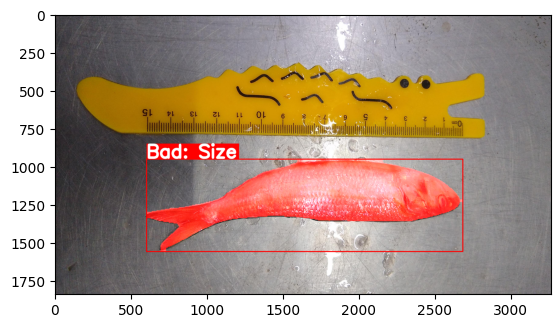

In [ ]:
rgb_img = cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_img);

In [ ]:
img_path = '/content/drive/MyDrive/Sowmya /New app testing data/input/2024-07-30/sardine/Good/2024-07-30_09:57:45_(13907)_sardine_input.jpeg'

In [ ]:
results = yolo_results(img_path, fish_model, conf=0.75, iou=0.7)
output_img = get_result_img(results)

,FishHeight,FishWidth,FishDiagonal,ScaleDiagonal,ScaleWidth,OnePixelValue,Circumference,Area
0,12,3,13,13,1,0.027426,28,31


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


[array([[    0.62531,     0.37469]])]
Bad: Soft


,FishHeight,FishWidth,FishDiagonal,ScaleDiagonal,ScaleWidth,OnePixelValue,Circumference,Area
0,12,3,12,13,1,0.027426,28,28


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


[array([[    0.88773,     0.11227]])]
Bad: Size


,FishHeight,FishWidth,FishDiagonal,ScaleDiagonal,ScaleWidth,OnePixelValue,Circumference,Area
0,12,2,12,13,1,0.027426,29,23


[array([[     0.9966,   0.0034046]])]
Bad: Size


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


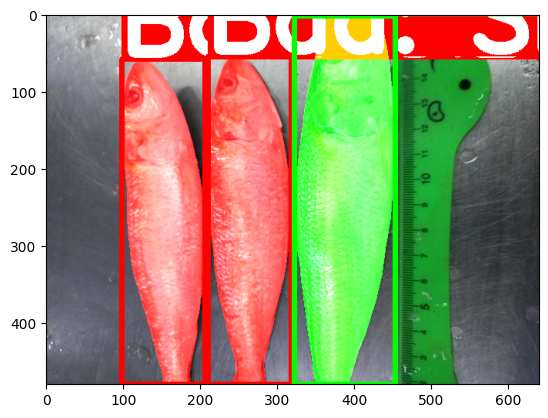

In [ ]:
rgb_img = cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_img);

,FishHeight,FishWidth,FishDiagonal,ScaleDiagonal,ScaleWidth,OnePixelValue,Circumference,Area
0,11,2,11,12,2,0.025,25,24


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


[array([[    0.99006,   0.0099437]])]
Bad: Size


,FishHeight,FishWidth,FishDiagonal,ScaleDiagonal,ScaleWidth,OnePixelValue,Circumference,Area
0,11,3,11,12,2,0.025,26,25


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


[array([[    0.97374,     0.02626]])]
Bad: Size


,FishHeight,FishWidth,FishDiagonal,ScaleDiagonal,ScaleWidth,OnePixelValue,Circumference,Area
0,8,2,9,12,2,0.025,21,19


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


[array([[    0.99959,  0.00040769]])]
Bad: Size


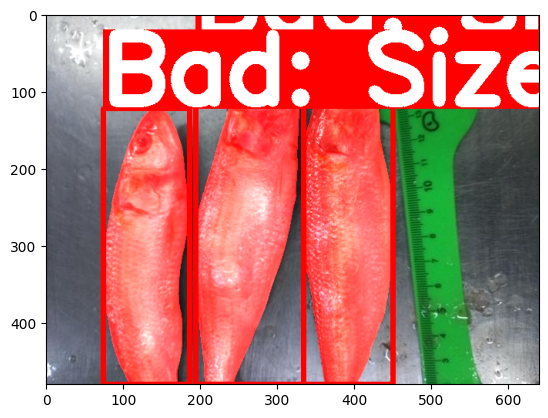

In [ ]:
img_path = '/content/drive/MyDrive/Sowmya /New app testing data/input/2024-07-16/sardine/Good/2024-07-16_11:00:48_(13739)_sardine_input.jpeg'
results = yolo_results(img_path, fish_model, conf=0.75, iou=0.7)
output_img = get_result_img(results)
rgb_img = cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_img);

,FishHeight,FishWidth,FishDiagonal,ScaleDiagonal,ScaleWidth,OnePixelValue,Circumference,Area
0,10,3,11,12,1,0.025918,25,22


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


[array([[    0.99557,   0.0044301]])]
Bad: Size


,FishHeight,FishWidth,FishDiagonal,ScaleDiagonal,ScaleWidth,OnePixelValue,Circumference,Area
0,10,2,10,12,1,0.025918,23,18


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


[array([[    0.99952,  0.00047747]])]
Bad: Size


,FishHeight,FishWidth,FishDiagonal,ScaleDiagonal,ScaleWidth,OnePixelValue,Circumference,Area
0,12,3,12,12,1,0.025918,29,25


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


[array([[    0.97976,    0.020239]])]
Bad: Size


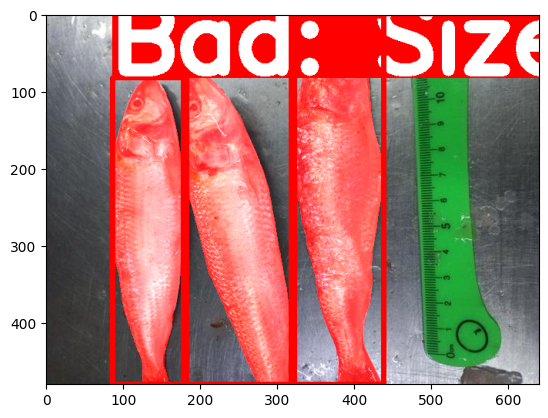

In [ ]:
img_path = '/content/drive/MyDrive/Sowmya /New app testing data/input/2024-07-16/sardine/Good/2024-07-16_11:01:12_(13740)_sardine_input.jpeg'
results = yolo_results(img_path, fish_model, conf=0.75, iou=0.7)
output_img = get_result_img(results)
rgb_img = cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_img);

Good
Bad: Soft
Bad: Soft


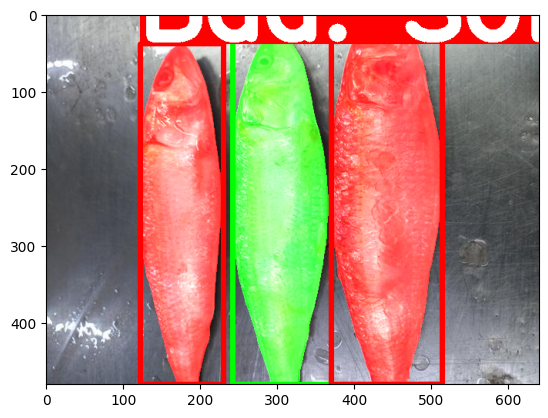

In [ ]:
img_path = '/content/drive/MyDrive/Sowmya /New app testing data/input/2024-07-16/sardine/Good/2024-07-16_11:09:49_(13745)_sardine_input.jpeg'
results = yolo_results(img_path, fish_model, conf=0.75, iou=0.7)
output_img = get_result_img(results)
rgb_img = cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_img);

In [ ]:
img_path = "/content/drive/MyDrive/Sowmya /App testing Dataset/sardine size test new/sardine/bad/Size, Cuts and Damage, Softness/20240330092912921_sardine_bad.jpeg"

In [ ]:
folder = "/content/drive/MyDrive/Sowmya /App testing Dataset/sardine size test new/sardine/bad/Size"
img_path = os.path.join(folder, '20240417102942218_sardine_bad.jpeg')

In [ ]:
results = yolo_results(img_path, fish_model, conf=0.75, iou=0.7)
output_img = get_result_img(results)

,FishHeight,FishWidth,FishDiagonal,ScaleDiagonal,ScaleWidth,OnePixelValue,Circumference,Area
0,14,3,15,16,1,0.008184,36,33


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


[array([[    0.66117,     0.33883]])]
Good


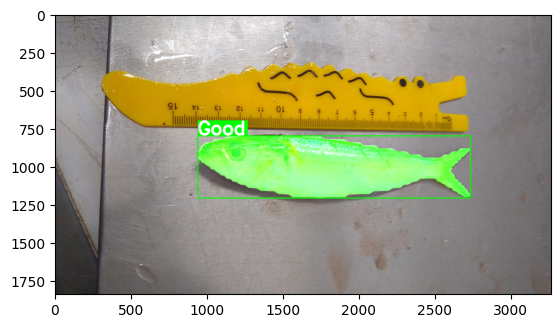

In [ ]:
rgb_img = cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_img);

In [ ]:
folder = "/content/drive/MyDrive/Sowmya /qZense Dataset/S3 Data/Daily Data/2024-05-02/Sardine/Bad/Single"
img_path = os.path.join(folder, '20240502101604319_sardine_bad.jpeg')

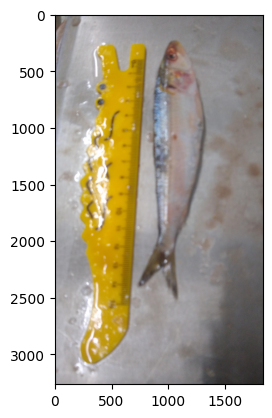

In [ ]:
plt.imshow(plt.imread(img_path));

In [ ]:
results = yolo_results(img_path, fish_model, conf=0.75, iou=0.7)
output_img = get_result_img(results)

,FishHeight,FishWidth,FishDiagonal,ScaleDiagonal,ScaleWidth,OnePixelValue,Circumference,Area
0,0,0,0,0,0,0,5425.007499,665040.0


[array([[          0,           1]])]
Good


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


# test a folder of images

In [ ]:
def get_result_img_with_reason_for_multiple_fish_data(results):
    # with size model
    obj_detected = len(results[0].boxes.cls)
    if obj_detected == 0:
        preds, reasons = ['No fish detected'], ['No fish detected']
    else:
        output_img = results[0].orig_img
        preds=[]
        reasons=[]
        for i in range(obj_detected):
            seg_img_list, mask, bbox = get_segmented_img(results[0], True, i)
            # Go to Cuts and damages model
            cuts = cuts_damages(seg_img_list)
            if (cuts==None) or (cuts == False):
                # go to scale detection model
                seg_img_list, mask, bbox = get_segmented_img(results[0], False, i)
                origi_img = results[0].orig_img
                res = yolo_results(origi_img, scale_model)
                if len(res[0].boxes.cls) == 0:
                    # print("No scale detected")
                    pred = softness_model_predict(seg_img_list, softness_model)
                    reason = 'Soft'
                    if pred == 'Good': reason = 'None'

                else:
                    # scale_seg_img, m, b = get_segmented_img(res[0])
                    # get the dimensions of the scale
                    scale_hp, scale_wp, scale_dp = get_object_height(res)
                    fish_hp, fish_wp, fish_dp = get_object_height(results, i)
                    df = single_img_data(fish_hp, fish_wp, fish_dp,
                                           scale_hp, scale_wp, scale_dp,
                                           seg_img_list)
                    # go to size based classification model
                    pred = pred_single_img(df, size_based_model)
                    if pred == 'Bad':
                        reason = 'Size'
                    else:
                        # go to softness model
                        pred = softness_model_predict(seg_img_list, softness_model)
                        reason = 'Soft'
                        if pred == 'Good': reason = 'None'

            else:
                pred = 'Bad'
                reason = 'Cuts'
            preds.append(pred)
            reasons.append(reason)
    return preds, reasons

In [ ]:
def get_result_img_with_reason_for_multiple_fish_data(results):
    # without size model
    obj_detected = len(results[0].boxes.cls)
    if obj_detected == 0:
        preds, reasons = ['No fish detected'], ['No fish detected']
    else:
        output_img = results[0].orig_img
        preds=[]
        reasons=[]
        for i in range(obj_detected):
            seg_img_list, mask, bbox = get_segmented_img(results[0], True, i)
            # Go to Cuts and damages model
            cuts = cuts_damages(seg_img_list)
            if (cuts==None) or (cuts == False):
                # go to scale detection model
                seg_img_list, mask, bbox = get_segmented_img(results[0], False, i)
                # origi_img = results[0].orig_img
                # res = yolo_results(origi_img, scale_model)
                # if len(res[0].boxes.cls) == 0:
                if True:
                    # print("No scale detected")
                    pred = softness_model_predict(seg_img_list, softness_model)
                    reason = 'Soft'
                    if pred == 'Good': reason = 'None'

                else:
                    # scale_seg_img, m, b = get_segmented_img(res[0])
                    # get the dimensions of the scale
                    scale_hp, scale_wp, scale_dp = get_object_height(res)
                    fish_hp, fish_wp, fish_dp = get_object_height(results, i)
                    df = single_img_data(fish_hp, fish_wp, fish_dp,
                                           scale_hp, scale_wp, scale_dp,
                                           seg_img_list)
                    # go to size based classification model
                    pred = pred_single_img(df, size_based_model)
                    if pred == 'Bad':
                        reason = 'Size'
                    else:
                        # go to softness model
                        pred = softness_model_predict(seg_img_list, softness_model)
                        reason = 'Soft'
                        if pred == 'Good': reason = 'None'

            else:
                pred = 'Bad'
                reason = 'Cuts'
            preds.append(pred)
            reasons.append(reason)
    return preds, reasons

In [111]:
def get_result_img_with_reason_for_multiple_fish_data(results):
    # without size model but with if condition
    obj_detected = len(results[0].boxes.cls)
    if obj_detected == 0:
        preds, reasons = ['No fish detected'], ['No fish detected']
    else:
        output_img = results[0].orig_img
        preds=[]
        reasons=[]
        for i in range(obj_detected):
            seg_img_list, mask, bbox = get_segmented_img(results[0], True, i)
            # Go to Cuts and damages model
            cuts = cuts_damages(seg_img_list)
            if (cuts==None) or (cuts == False):
                # go to scale detection model
                seg_img_list, mask, bbox = get_segmented_img(results[0], False, i)
                origi_img = results[0].orig_img
                res = yolo_results(origi_img, scale_model)
                if len(res[0].boxes.cls) == 0:
                # if True:
                    # print("No scale detected")
                    pred = softness_model_predict(seg_img_list, softness_model)
                    reason = 'Soft'
                    if pred == 'Good': reason = 'None'

                else:
                    # scale_seg_img, m, b = get_segmented_img(res[0])
                    # get the dimensions of the scale
                    scale_hp, scale_wp, scale_dp = get_object_height(res)
                    fish_hp, fish_wp, fish_dp = get_object_height(results, i)
                    df = single_img_data(fish_hp, fish_wp, fish_dp,
                                           scale_hp, scale_wp, scale_dp,
                                           seg_img_list)
                    # go to size based classification model
                    # pred = pred_single_img(df, size_based_model)
                    pred = 'Good'
                    # FishDiagonal FishHeight
                    if df.iloc[0]['FishDiagonal'] < 12:
                        display(df)
                        print('Fish height less than 12', df.iloc[0]['FishHeight'])
                        pred = 'Bad'
                    if pred == 'Bad':
                        reason = 'Size'
                    else:
                        # go to softness model
                        pred = softness_model_predict(seg_img_list, softness_model)
                        reason = 'Soft'
                        if pred == 'Good': reason = 'None'

            else:
                pred = 'Bad'
                reason = 'Cuts'
            preds.append(pred)
            reasons.append(reason)
    return preds, reasons

In [36]:
def get_result_img_with_reason(results):
    obj_detected = len(results[0].boxes.cls)
    if obj_detected == 0:
        pred, reason = 'No fish detected', 'No fish detected'
    else:
        output_img = results[0].orig_img
        for i in range(obj_detected):
            seg_img_list, mask, bbox = get_segmented_img(results[0], True, i)
            # Go to Cuts and damages model
            cuts = cuts_damages(seg_img_list)
            if (cuts==None) or (cuts == False):
                # go to scale detection model
                seg_img_list, mask, bbox = get_segmented_img(results[0], False, i)
                orig_img = results[0].orig_img
                res = yolo_results(orig_img, scale_model)
                if len(res[0].boxes.cls) == 0:
                    # print("No scale detected")
                    pred = softness_model_predict(seg_img_list, softness_model)
                    reason = 'Soft'
                    if pred == 'Good': reason = 'None'

                else:
                    # scale_seg_img, m, b = get_segmented_img(res[0])
                    # get the dimensions of the scale
                    scale_hp, scale_wp, scale_dp = get_object_height(res)
                    fish_hp, fish_wp, fish_dp = get_object_height(results, i)
                    df = single_img_data(fish_hp, fish_wp, fish_dp,
                                           scale_hp, scale_wp, scale_dp,
                                           seg_img_list)
                    # go to size based classification model
                    pred = pred_single_img(df, size_based_model)
                    if pred == 'Bad':
                        reason = 'Size'
                    else:
                        # go to softness model
                        pred = softness_model_predict(seg_img_list, softness_model)
                        reason = 'Soft'
                        if pred == 'Good': reason = 'None'

            else:
                pred = 'Bad'
                reason = 'Cuts'
    return pred, reason

In [37]:
from tqdm import tqdm
def get_df_for_folder(single_folder_path):
    print(single_folder_path)
    data = []
    for filename in tqdm(os.listdir(single_folder_path)):
        img_path = os.path.join(single_folder_path, filename)
        if not os.path.isfile(img_path): continue
        results = yolo_results(img_path, fish_model, conf=0.75, iou=0.7)
        pred, reason = get_result_img_with_reason_for_multiple_fish_data(results)
        filenames=[filename]*len(pred)
        data.append([filenames, pred, reason])

    # Create lists for each column
    filename_list = []
    pred_list = []
    reason_list = []

    # Iterate through the nested list and extract values
    for sublist in data:
        filename_list.extend(sublist[0])
        pred_list.extend(sublist[1])
        reason_list.extend(sublist[2])

    new_df = pd.DataFrame({'filename': filename_list,
                           'pred': pred_list,
                           'reason': reason_list})
    return new_df

In [38]:
def test_multiple_folders(folder_path):
    dfs=[]
    for date in os.listdir(folder_path):
        species_folder_path = os.path.join(folder_path, date, 'sardine')
        if not os.path.isdir(species_folder_path): continue
        for folder in os.listdir(species_folder_path):
            single_folder_path = os.path.join(species_folder_path, folder)
            new_df = get_df_for_folder(single_folder_path)
            new_df['actual'] = folder
            # new_df['Date'] = new_df['filename'].str[:10]
            dfs.append(new_df)
    return pd.concat(dfs)

In [135]:
def test_multiple_folders(folder_path):
    dfs=[]
    for date in os.listdir(folder_path):
        if date!='2024-07-30': continue
        species_folder_path = os.path.join(folder_path, date, 'sardine')
        if not os.path.isdir(species_folder_path): continue
        for folder in os.listdir(species_folder_path):
            single_folder_path = os.path.join(species_folder_path, folder)
            new_df = get_df_for_folder(single_folder_path)
            new_df['actual'] = folder
            # new_df['Date'] = new_df['filename'].str[:10]
            dfs.append(new_df)
    return pd.concat(dfs)

In [136]:
folder_path = "/content/drive/MyDrive/Sowmya /New app testing data/input"
df = test_multiple_folders(folder_path)
df

/content/drive/MyDrive/Sowmya /New app testing data/input/2024-07-30/sardine/Good


 57%|█████▋    | 8/14 [00:54<00:37,  6.28s/it]

,FishHeight,FishWidth,FishDiagonal,ScaleDiagonal,ScaleWidth,OnePixelValue,Circumference,Area
0,11,2,11,13,2,0.02766,26,22


Fish height less than 12 11.0


 79%|███████▊  | 11/14 [01:11<00:18,  6.10s/it]

...

 93%|█████████▎| 13/14 [01:24<00:06,  6.31s/it]

,FishHeight,FishWidth,FishDiagonal,ScaleDiagonal,ScaleWidth,OnePixelValue,Circumference,Area
0,11,2,11,13,2,0.027083,25,19


100%|██████████| 14/14 [01:29<00:00,  6.37s/it]

Fish height less than 12 11.0


,filename,pred,reason,actual
0,2024-07-30_09:56:55_(13905)_sardine_input.jpeg,Good,None,Good
1,2024-07-30_09:56:55_(13905)_sardine_input.jpeg,Good,None,Good
2,2024-07-30_09:56:55_(13905)_sardine_input.jpeg,Good,None,Good
3,2024-07-30_09:57:24_(13906)_sardine_input.jpeg,Good,None,Good
4,2024-07-30_09:57:24_(13906)_sardine_input.jpeg,Good,None,Good
5,2024-07-30_09:57:24_(13906)_sardine_input.jpeg,Good,None,Good
6,2024-07-30_09:57:45_(13907)_sardine_input.jpeg,Bad,Soft,Good
7,2024-07-30_09:57:45_(13907)_sardine_input.jpeg,Good,None,Good
8,2024-07-30_09:57:45_(13907)_sardine_input.jpeg,Bad,Soft,Good
9,2024-07-30_09:58:06_(13908)_sardine_input.jpeg,Bad,Soft,Good


Actual good but predicted bad due to size less than 12cm

1.   2024-07-16_11:00:48_(13739)_sardine_input.jpeg
2.   2024-07-16_11:01:12_(13740)_sardine_input.jpeg



In [137]:
new_df = df
acc = new_df[new_df['actual']==new_df['pred']].shape[0]/new_df.shape[0]*100
print("model accuracy = ", acc)

model accuracy =  51.162790697674424


In [138]:
folder = '/content/drive/MyDrive/Sowmya /New app testing data/'
# filename = 'v12 app testing data till july 14 with current model.csv'
# filename = 'v12 app testing data on july 16 with current model.csv'
filename = 'v12 app testing data on july 16 with current model 0.8th.csv'

# filename = 'test_entire_app_testing_data_till_may14_with_current_model_in_the_app.csv'
# filename = 'test_entire_app_testing_data_till_may14_with_karthik_model_in_the_app.csv'
filepath = os.path.join(folder, filename)

In [139]:
df['Date'] = df['filename'].str[:10]
df.to_csv(filepath, index=False)

In [140]:
p = pd.read_csv(filepath)

In [141]:
p

,filename,pred,reason,actual,Date
0,2024-07-30_09:56:55_(13905)_sardine_input.jpeg,Good,NaN,Good,2024-07-30
1,2024-07-30_09:56:55_(13905)_sardine_input.jpeg,Good,NaN,Good,2024-07-30
2,2024-07-30_09:56:55_(13905)_sardine_input.jpeg,Good,NaN,Good,2024-07-30
3,2024-07-30_09:57:24_(13906)_sardine_input.jpeg,Good,NaN,Good,2024-07-30
4,2024-07-30_09:57:24_(13906)_sardine_input.jpeg,Good,NaN,Good,2024-07-30
5,2024-07-30_09:57:24_(13906)_sardine_input.jpeg,Good,NaN,Good,2024-07-30
6,2024-07-30_09:57:45_(13907)_sardine_input.jpeg,Bad,Soft,Good,2024-07-30
7,2024-07-30_09:57:45_(13907)_sardine_input.jpeg,Good,NaN,Good,2024-07-30
8,2024-07-30_09:57:45_(13907)_sardine_input.jpeg,Bad,Soft,Good,2024-07-30
9,2024-07-30_09:58:06_(13908)_sardine_input.jpeg,Bad,Soft,Good,2024-07-30


In [142]:
new_df = p[p['reason']=='Soft']

In [ ]:
acc = new_df[new_df['actual']==new_df['pred']].shape[0]/new_df.shape[0]*100
print("model accuracy = ", acc)

model accuracy =  100.0


In [ ]:
def test_multiple_folders_after_date(folder_path):
    # for s3 daily data
    dfs=[]
    for date in sorted(os.listdir(folder_path)):
        if date < '2024-06-10': continue
        species_folder_path = os.path.join(folder_path, date, 'Sardine')
        if not os.path.isdir(species_folder_path): continue
        for folder in os.listdir(species_folder_path):
            single_folder_path = os.path.join(species_folder_path, folder, 'Single')
            if not os.path.isdir(single_folder_path): continue
            new_df = get_df_for_folder(single_folder_path)
            new_df['actual'] = folder
            # new_df['Date'] = new_df['filename'].str[:10]
            dfs.append(new_df)
    return pd.concat(dfs)

In [ ]:
folder_path = "/content/drive/MyDrive/Sowmya /qZense Dataset/S3 Data/Daily Data"
df = test_multiple_folders_after_date(folder_path)
df

/content/drive/MyDrive/Sowmya /qZense Dataset/S3 Data/Daily Data/2024-06-11/Sardine/Bad/Single


  0%|          | 0/112 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
  1%|          | 1/112 [00:00<01:05,  1.70it/s]

[array([[   0.020952,     0.97905]])]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
  2%|▏         | 2/112 [00:01<01:09,  1.59it/s]

[array([[    0.75696,     0.24304]])]


...

[array([[    0.02121,     0.97879]])]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
 98%|█████████▊| 44/45 [00:16<00:00,  2.85it/s]

[array([[          0,           1]])]


100%|██████████| 45/45 [00:16<00:00,  2.76it/s]


,filename,pred,reason,actual
0,20240611094944431_sardine_bad.jpeg,Good,None,Bad
1,20240611094954923_sardine_bad.jpeg,Bad,Size,Bad
2,20240611095004863_sardine_bad.jpeg,Good,None,Bad
3,20240611095014141_sardine_bad.jpeg,Bad,Soft,Bad
4,20240611095025742_sardine_bad.jpeg,Bad,Cuts,Bad
...,...,...,...,...
40,20240713113700550_sardine_bad.jpeg,Good,None,Bad
41,20240713113713607_sardine_bad.jpeg,Good,None,Bad
42,20240713113722376_sardine_bad.jpeg,Bad,Soft,Bad
43,20240713113734833_sardine_bad.jpeg,Bad,Soft,Bad


In [ ]:
folder = '/content/drive/MyDrive/Sowmya /New app testing data/'
filename = 'v12 data collection data june10 to july 14 with 0.7th current model.csv'
# filename = 'testresultsof_data_collected_from_may_24_till_june10_with_0.7th_current_model_in_the_app.csv'
# filename = 'test_entire_app_testing_data_till_may14_with_karthik_model_in_the_app.csv'
filepath = os.path.join(folder, filename)

In [ ]:
df['Date'] = df['filename'].str[:8]
df.to_csv(filepath, index=False)

In [ ]:
filepath

'/content/drive/MyDrive/Sowmya /New app testing data/v12 data collection data june10 to july 14 with 0.7th current model.csv'

In [ ]:
p = pd.read_csv(filepath)

In [ ]:
p

,filename,pred,reason,actual,Date
0,20240611094944431_sardine_bad.jpeg,Good,NaN,Bad,20240611
1,20240611094954923_sardine_bad.jpeg,Bad,Size,Bad,20240611
2,20240611095004863_sardine_bad.jpeg,Good,NaN,Bad,20240611
3,20240611095014141_sardine_bad.jpeg,Bad,Soft,Bad,20240611
4,20240611095025742_sardine_bad.jpeg,Bad,Cuts,Bad,20240611
...,...,...,...,...,...
643,20240713113700550_sardine_bad.jpeg,Good,NaN,Bad,20240713
644,20240713113713607_sardine_bad.jpeg,Good,NaN,Bad,20240713
645,20240713113722376_sardine_bad.jpeg,Bad,Soft,Bad,20240713
646,20240713113734833_sardine_bad.jpeg,Bad,Soft,Bad,20240713


In [ ]:
p['actual'].value_counts()

actual
Bad     600
Good     47
Ok        1
Name: count, dtype: int64

In [ ]:
new_df = p

In [ ]:
bad_df = new_df[new_df['actual']=='Bad']
new_df = bad_df


In [ ]:
acc = new_df[new_df['actual']==new_df['pred']].shape[0]/new_df.shape[0]*100
print("model accuracy = ", acc)

model accuracy =  90.83333333333333


In [ ]:
folder_path = "/content/drive/MyDrive/Sowmya /qZense Dataset/S3 Data/Daily Data/2024-05-02/Sardine/Bad"
from tqdm import tqdm

data = []
for filename in tqdm(os.listdir(folder_path)):
    img_path = os.path.join(folder_path, filename)
    if not os.path.isfile(img_path): continue
    results = yolo_results(img_path, fish_model, conf=0.75, iou=0.7)
    pred, reason = get_result_img_with_reason(results)
    data.append([filename, pred, reason])
new_df = pd.DataFrame(data, columns=['filename', 'pred', 'reason'])

  2%|▏         | 1/48 [00:00<00:40,  1.16it/s]/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


[array([[          0,           1]])]
[array([[          0,           1]])]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
  4%|▍         | 2/48 [00:01<00:40,  1.14it/s]

[array([[          0,           1]])]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


...

[array([[          0,           1]])]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


[array([[          0,           1]])]
[array([[          0,           1]])]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
100%|██████████| 48/48 [00:39<00:00,  1.21it/s]

[array([[          0,           1]])]


In [ ]:
new_df

,filename,pred,reason
0,2024-06-11_09:43:52_(13475)_sardine_input.jpeg,Good,None
1,2024-06-11_09:44:14_(13476)_sardine_input.jpeg,Good,None
2,2024-06-11_09:44:33_(13477)_sardine_input.jpeg,Good,None
3,2024-06-11_09:44:55_(13478)_sardine_input.jpeg,Good,None
4,2024-06-11_09:45:24_(13479)_sardine_input.jpeg,Good,None
5,2024-06-11_09:45:47_(13480)_sardine_input.jpeg,Good,None
6,2024-06-11_09:46:08_(13481)_sardine_input.jpeg,Good,None
7,2024-06-11_09:46:29_(13482)_sardine_input.jpeg,Good,None
8,2024-06-11_09:47:15_(13483)_sardine_input.jpeg,Good,None
9,2024-06-11_09:47:36_(13484)_sardine_input.jpeg,Good,None


In [ ]:
new_df['pred'].value_counts()

pred
Good    35
Bad     13
Name: count, dtype: int64

In [ ]:
47+106

In [ ]:
new_df['reason'].value_counts()

reason
None    35
Soft     8
Cuts     5
Name: count, dtype: int64

In [ ]:
new_df[new_df['filename']=='20240502101213407_sardine_bad.jpeg']

,filename,pred,reason
36,20240502101213407_sardine_bad.jpeg,Bad,Cuts


In [ ]:
import matplotlib.pyplot as plt

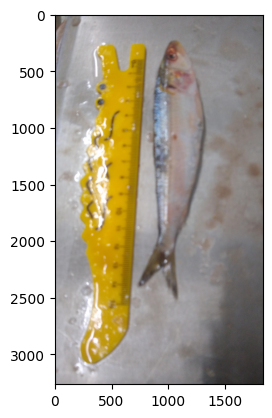

In [ ]:
filepath = "/content/drive/MyDrive/Sowmya /qZense Dataset/S3 Data/Daily Data/2024-05-02/Sardine/Bad/20240502101604319_sardine_bad.jpeg"
plt.imshow(plt.imread(filepath));

In [ ]:
new_df[new_df['reason']=='Size']

,filename,pred,reason
3,20240502100619414_sardine_bad.jpeg,Bad,Size
23,20240502100933075_sardine_bad.jpeg,Bad,Size
25,20240502100950606_sardine_bad.jpeg,Bad,Size
40,20240502101311749_sardine_bad.jpeg,Bad,Size
49,20240502101529858_sardine_bad.jpeg,Bad,Size
64,20240502101748311_sardine_bad.jpeg,Bad,Size
80,20240502102042658_sardine_bad.jpeg,Bad,Size
85,20240502102217591_sardine_bad.jpeg,Bad,Size
96,20240502102402067_sardine_bad.jpeg,Bad,Size
124,20240502102903984_sardine_bad.jpeg,Bad,Size


In [ ]:
folder_path = "/content/drive/MyDrive/Sowmya /qZense Dataset/S3 Data/Daily Data/2024-04-30/Sardine/Bad"
from tqdm import tqdm

data = []
for filename in tqdm(os.listdir(folder_path)):
    img_path = os.path.join(folder_path, filename)
    if not os.path.isfile(img_path): continue
    results = yolo_results(img_path, fish_model, conf=0.75, iou=0.7)
    pred, reason = get_result_img_with_reason(results)
    data.append([filename, pred, reason])
new_df2 = pd.DataFrame(data, columns=['filename', 'pred', 'reason'])

  0%|          | 0/206 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
  0%|          | 1/206 [00:03<11:42,  3.43s/it]

[array([[    0.98618,    0.013821]])]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


[array([[    0.22775,     0.77225]])]


  1%|▏         | 3/206 [00:15<18:57,  5.61s/it]/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


...

 92%|█████████▏| 189/206 [12:08<01:00,  3.56s/it]/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


[array([[    0.33946,     0.66054]])]


 92%|█████████▏| 190/206 [12:12<00:55,  3.49s/it]/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


[array([[    0.51384,     0.48616]])]


100%|██████████| 206/206 [13:22<00:00,  3.90s/it]


In [ ]:
new_df2['pred'].value_counts()

pred
Good                113
Bad                  92
No fish detected      1
Name: count, dtype: int64

In [ ]:
new_df2['reason'].value_counts()

reason
None                113
Cuts                 42
Soft                 26
Size                 24
No fish detected      1
Name: count, dtype: int64

In [ ]:
folder_path = "/content/drive/MyDrive/Sowmya /App testing Dataset/sardine size test new/sardine/bad/Size"
from tqdm import tqdm

data = []
for filename in tqdm(os.listdir(folder_path)):
    img_path = os.path.join(folder_path, filename)
    if not os.path.isfile(img_path): continue
    results = yolo_results(img_path, fish_model, conf=0.75, iou=0.7)
    pred, reason = get_result_img_with_reason(results)
    data.append([filename, pred, reason])
df1 = pd.DataFrame(data, columns=['filename', 'pred', 'reason'])

  0%|          | 0/27 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
  4%|▎         | 1/27 [00:06<02:39,  6.13s/it]

[array([[    0.90799,    0.092012]])]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
  7%|▋         | 2/27 [00:13<02:44,  6.60s/it]

[array([[    0.85683,     0.14317]])]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


...

[array([[    0.66117,     0.33883]])]


 89%|████████▉ | 24/27 [01:32<00:08,  2.88s/it]/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


[array([[    0.58285,     0.41715]])]


 93%|█████████▎| 25/27 [01:35<00:05,  2.84s/it]/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
100%|██████████| 27/27 [01:37<00:00,  3.62s/it]

[array([[    0.83212,     0.16788]])]


## EDA

In [ ]:
df1

,filename,pred,reason
0,20240417102631643_sardine_bad.jpeg,Bad,Size
1,20240417102643462_sardine_bad.jpeg,Bad,Size
2,20240417102715968_sardine_bad.jpeg,Bad,Soft
3,20240417102748006_sardine_bad.jpeg,Bad,Soft
4,20240417102951616_sardine_bad.jpeg,Bad,Soft
5,20240405102558943_sardine_bad.jpeg,Good,Soft
6,20240417102137528_sardine_bad.jpeg,Good,Soft
7,20240417102151649_sardine_bad.jpeg,Good,Soft
8,20240417102200957_sardine_bad.jpeg,Good,Soft
9,20240417102210305_sardine_bad.jpeg,Bad,Size


In [ ]:
df1['pred'].value_counts()

pred
Bad     16
Good    10
Name: count, dtype: int64

In [ ]:
df1[df1['pred']=='Bad']['reason'].value_counts()

reason
Size    13
Soft     3
Name: count, dtype: int64

In [ ]:
df1[(df1['pred']=='Bad')&(df1['reason']=='Size')]

,filename,pred,reason
0,20240417102631643_sardine_bad.jpeg,Bad,Size
1,20240417102643462_sardine_bad.jpeg,Bad,Size
9,20240417102210305_sardine_bad.jpeg,Bad,Size
12,20240417102238241_sardine_bad.jpeg,Bad,Size
13,20240417102620472_sardine_bad.jpeg,Bad,Size
14,20240417102654279_sardine_bad.jpeg,Bad,Size
15,20240417102704655_sardine_bad.jpeg,Bad,Size
16,20240417102725388_sardine_bad.jpeg,Bad,Size
17,20240417102736734_sardine_bad.jpeg,Bad,Size
19,20240417102818990_sardine_bad.jpeg,Bad,Size


In [ ]:
df1[(df1['pred']=='Bad')&(df1['reason']=='Soft')]

,filename,pred,reason
2,20240417102715968_sardine_bad.jpeg,Bad,Soft
3,20240417102748006_sardine_bad.jpeg,Bad,Soft
4,20240417102951616_sardine_bad.jpeg,Bad,Soft


In [ ]:
df1[(df1['pred']=='Bad')&(df1['reason']=='Cuts')]

,filename,pred,reason


In [ ]:
df1[(df1['pred']=='Good')]['reason'].value_counts()

reason
Soft    10
Name: count, dtype: int64

## test good images

In [ ]:
folder_path = "/content/drive/MyDrive/Sowmya /qZense Dataset/S3 Data/Daily Data/2024-04-17/Sardine/Good/Single"
from tqdm import tqdm

data = []
for filename in tqdm(os.listdir(folder_path)):
    img_path = os.path.join(folder_path, filename)
    if not os.path.isfile(img_path): continue
    results = yolo_results(img_path, fish_model, conf=0.75, iou=0.7)
    pred, reason = get_result_img_with_reason(results)
    data.append([filename, pred, reason])
df = pd.DataFrame(data, columns=['filename', 'pred', 'reason'])

  0%|          | 0/32 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


[array([[          0,           1]])]


  3%|▎         | 1/32 [00:05<02:36,  5.04s/it]/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


[array([[    0.25825,     0.74175]])]


  9%|▉         | 3/32 [00:21<03:35,  7.43s/it]/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


...

 94%|█████████▍| 30/32 [02:19<00:08,  4.09s/it]/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


[array([[  0.0055478,     0.99445]])]


 97%|█████████▋| 31/32 [02:22<00:03,  3.91s/it]/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


[array([[  0.0033302,     0.99667]])]


100%|██████████| 32/32 [02:27<00:00,  4.62s/it]


In [ ]:
df

,filename,pred,reason
0,20240417094119428_sardine_good.jpeg,Good,Soft
1,20240417094128139_sardine_good.jpeg,Good,Soft
2,20240417094138523_sardine_good.jpeg,Bad,Cuts
3,20240417094148792_sardine_good.jpeg,Good,Soft
4,20240417094156839_sardine_good.jpeg,Good,Soft
5,20240417094206248_sardine_good.jpeg,Good,Soft
6,20240417094223081_sardine_good.jpeg,Good,Soft
7,20240417094246922_sardine_good.jpeg,Good,Soft
8,20240417094257799_sardine_good.jpeg,Good,Soft
9,20240417094313912_sardine_good.jpeg,Good,Soft


In [ ]:
df['pred'].value_counts()

pred
Good    28
Bad      4
Name: count, dtype: int64

In [ ]:
df[df['pred']=='Good']['reason'].value_counts()

reason
Soft    28
Name: count, dtype: int64

In [ ]:
df[(df['pred']=='Bad')]['reason'].value_counts()

reason
Cuts    2
Soft    2
Name: count, dtype: int64

In [ ]:
folder_path = "/content/drive/MyDrive/Sowmya /App testing Dataset/sardine size test new/sardine/bad/Size, Cuts and Damage, Softness"
from tqdm import tqdm

data = []
for filename in tqdm(os.listdir(folder_path)):
    img_path = os.path.join(folder_path, filename)
    if not os.path.isfile(img_path): continue
    results = yolo_results(img_path, fish_model, conf=0.75, iou=0.7)
    pred, reason = get_result_img_with_reason(results)
    data.append([filename, pred, reason])
df2 = pd.DataFrame(data, columns=['filename', 'pred', 'reason'])

100%|██████████| 2/2 [00:11<00:00,  5.71s/it]


In [ ]:
df2

,filename,pred,reason
0,20240327093111236_sardine_bad.jpeg,Bad,Cuts
1,20240330092912921_sardine_bad.jpeg,Bad,Cuts


In [ ]:
folder_path = "/content/drive/MyDrive/Sowmya /App testing Dataset/sardine size test new/sardine/bad/Size, Softness"
from tqdm import tqdm

data = []
for filename in tqdm(os.listdir(folder_path)):
    img_path = os.path.join(folder_path, filename)
    if not os.path.isfile(img_path): continue
    results = yolo_results(img_path, fish_model, conf=0.75, iou=0.7)
    pred, reason = get_result_img_with_reason(results)
    data.append([filename, pred, reason])
df3 = pd.DataFrame(data, columns=['filename', 'pred', 'reason'])

  0%|          | 0/5 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


[array([[          0,           1]])]


 20%|██        | 1/5 [00:05<00:22,  5.61s/it]/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


[array([[          0,           1]])]


 40%|████      | 2/5 [00:11<00:17,  5.77s/it]/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
 60%|██████    | 3/5 [00:16<00:11,  5.62s/it]

[array([[     0.9975,   0.0024952]])]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


[array([[          0,           1]])]


 80%|████████  | 4/5 [00:20<00:04,  4.94s/it]/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
100%|██████████| 5/5 [00:24<00:00,  4.81s/it]

[array([[    0.84141,     0.15859]])]


In [ ]:
df3

,filename,pred,reason
0,20240405100746955_sardine_bad.jpeg,Good,Soft
1,20240405102357761_sardine_bad.jpeg,Good,Soft
2,20240405102434851_sardine_bad.jpeg,Bad,Size
3,20240417102312948_sardine_bad.jpeg,Good,Soft
4,20240417102559908_sardine_bad.jpeg,Bad,Size


In [ ]:
folder_path = "/content/drive/MyDrive/Sowmya /App testing Dataset/sardine size test new/sardine/bad/Size, Softness, Cuts and Damage"
from tqdm import tqdm

data = []
for filename in tqdm(os.listdir(folder_path)):
    img_path = os.path.join(folder_path, filename)
    if not os.path.isfile(img_path): continue
    results = yolo_results(img_path, fish_model, conf=0.75, iou=0.7)
    pred, reason = get_result_img_with_reason(results)
    data.append([filename, pred, reason])
df4 = pd.DataFrame(data, columns=['filename', 'pred', 'reason'])

  0%|          | 0/1 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


[array([[          0,           1]])]


100%|██████████| 1/1 [00:04<00:00,  4.49s/it]


In [ ]:
df4

,filename,pred,reason
0,20240405103357587_sardine_bad.jpeg,Good,Soft


In [ ]:
folder_path = "/content/drive/MyDrive/Sowmya /App testing Dataset/sardine size test new/sardine/bad/Softness, Cuts and Damage, Size"
from tqdm import tqdm

data = []
for filename in tqdm(os.listdir(folder_path)):
    img_path = os.path.join(folder_path, filename)
    if not os.path.isfile(img_path): continue
    results = yolo_results(img_path, fish_model, conf=0.75, iou=0.7)
    pred, reason = get_result_img_with_reason(results)
    data.append([filename, pred, reason])
df5 = pd.DataFrame(data, columns=['filename', 'pred', 'reason'])

100%|██████████| 1/1 [00:03<00:00,  3.64s/it]


In [ ]:
df5

,filename,pred,reason
0,20240405103828114_sardine_bad.jpeg,Bad,Cuts


In [ ]:
folder_path = "/content/drive/MyDrive/Sowmya /App testing Dataset/sardine size test new/sardine/bad/Softness, Size"
from tqdm import tqdm

data = []
for filename in tqdm(os.listdir(folder_path)):
    img_path = os.path.join(folder_path, filename)
    if not os.path.isfile(img_path): continue
    results = yolo_results(img_path, fish_model, conf=0.75, iou=0.7)
    pred, reason = get_result_img_with_reason(results)
    data.append([filename, pred, reason])
df6 = pd.DataFrame(data, columns=['filename', 'pred', 'reason'])

  0%|          | 0/3 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
 33%|███▎      | 1/3 [00:03<00:06,  3.01s/it]

[array([[    0.99842,   0.0015807]])]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
 67%|██████▋   | 2/3 [00:08<00:04,  4.60s/it]

[array([[    0.99552,   0.0044828]])]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


[array([[    0.75654,     0.24346]])]


100%|██████████| 3/3 [00:12<00:00,  4.22s/it]


In [ ]:
df6

,filename,pred,reason
0,20240405095138191_sardine_bad.jpeg,Bad,Size
1,20240417102456489_sardine_bad.jpeg,Bad,Size
2,20240417102611208_sardine_bad.jpeg,Good,Soft


# move misclassified images

In [ ]:
import shutil
folder_path = "/content/drive/MyDrive/Sowmya /App testing Dataset/sardine size test new/sardine/bad/Size"
dest = os.path.join(folder_path, 'Misclassified')
os.makedirs(dest, exist_ok=True)

l = df[df['pred']=='Good']['filename'].tolist()
for filename in tqdm(l): # l is the list of misclassified images filenames:
    filepath = os.path.join(folder_path, filename)
    shutil.move(filepath, dest)

100%|██████████| 82/82 [00:01<00:00, 67.31it/s]


# test a folder of images without size model

In [ ]:
def get_result_img_with_reason_without_size(results):
    obj_detected = len(results[0].boxes.cls)
    if obj_detected == 0:
        pred, reason = 'No fish detected', 'No fish detected'
    else:
        output_img = results[0].orig_img
        for i in range(obj_detected):
            seg_img_list, mask, bbox = get_segmented_img(results[0], True, i)
            # Go to Cuts and damages model
            cuts = cuts_damages(seg_img_list)
            if (cuts==None) or (cuts == False):
                    pred = softness_model_predict(seg_img_list, softness_model)
                    reason = 'Soft'
                    if pred == 'Good': reason = 'None'
            else:
                pred = 'Bad'
                reason = 'Cuts'
    return pred, reason

In [ ]:
folder_path = "/content/drive/MyDrive/Sowmya /App testing Dataset/sardine size test new/sardine/bad/Size"
from tqdm import tqdm

data = []
for filename in tqdm(os.listdir(folder_path)):
    img_path = os.path.join(folder_path, filename)
    if not os.path.isfile(img_path): continue
    results = yolo_results(img_path, fish_model, conf=0.75, iou=0.7)
    pred, reason = get_result_img_with_reason_without_size(results)
    data.append([filename, pred, reason])
df_old_model1 = pd.DataFrame(data, columns=['filename', 'pred', 'reason'])

100%|██████████| 27/27 [01:52<00:00,  4.16s/it]


In [ ]:
df_old_model1['pred'].value_counts()

pred
Good    25
Bad      1
Name: count, dtype: int64

In [ ]:
folder_path = "/content/drive/MyDrive/Sowmya /App testing Dataset/sardine size test new/sardine/bad/Size, Cuts and Damage, Softness"
from tqdm import tqdm

data = []
for filename in tqdm(os.listdir(folder_path)):
    img_path = os.path.join(folder_path, filename)
    if not os.path.isfile(img_path): continue
    results = yolo_results(img_path, fish_model, conf=0.75, iou=0.7)
    pred, reason = get_result_img_with_reason_without_size(results)
    data.append([filename, pred, reason])
df_old_model2 = pd.DataFrame(data, columns=['filename', 'pred', 'reason'])

100%|██████████| 2/2 [00:08<00:00,  4.18s/it]


In [ ]:
df_old_model2

,filename,pred,reason
0,20240327093111236_sardine_bad.jpeg,Bad,Cuts
1,20240330092912921_sardine_bad.jpeg,Bad,Cuts


In [ ]:
folder_path = "/content/drive/MyDrive/Sowmya /App testing Dataset/sardine size test new/sardine/bad/Size, Softness"
from tqdm import tqdm

data = []
for filename in tqdm(os.listdir(folder_path)):
    img_path = os.path.join(folder_path, filename)
    if not os.path.isfile(img_path): continue
    results = yolo_results(img_path, fish_model, conf=0.75, iou=0.7)
    pred, reason = get_result_img_with_reason_without_size(results)
    data.append([filename, pred, reason])
df_old_model3 = pd.DataFrame(data, columns=['filename', 'pred', 'reason'])

100%|██████████| 5/5 [00:27<00:00,  5.59s/it]


In [ ]:
df_old_model3

,filename,pred,reason
0,20240405100746955_sardine_bad.jpeg,Good,None
1,20240405102357761_sardine_bad.jpeg,Good,None
2,20240405102434851_sardine_bad.jpeg,Good,None
3,20240417102312948_sardine_bad.jpeg,Good,None
4,20240417102559908_sardine_bad.jpeg,Good,None


In [ ]:
folder_path = "/content/drive/MyDrive/Sowmya /App testing Dataset/sardine size test new/sardine/bad/Size, Softness, Cuts and Damage"
from tqdm import tqdm

data = []
for filename in tqdm(os.listdir(folder_path)):
    img_path = os.path.join(folder_path, filename)
    if not os.path.isfile(img_path): continue
    results = yolo_results(img_path, fish_model, conf=0.75, iou=0.7)
    pred, reason = get_result_img_with_reason_without_size(results)
    data.append([filename, pred, reason])
df_old_model4 = pd.DataFrame(data, columns=['filename', 'pred', 'reason'])

100%|██████████| 1/1 [00:06<00:00,  6.88s/it]


In [ ]:
df_old_model4

,filename,pred,reason
0,20240405103357587_sardine_bad.jpeg,Good,None


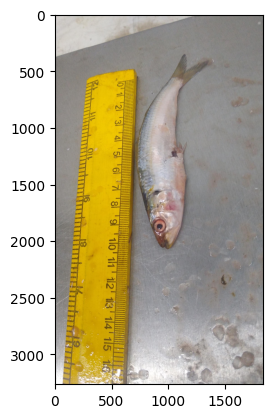

In [ ]:
folder_path = "/content/drive/MyDrive/Sowmya /App testing Dataset/sardine size test new/sardine/bad/Size, Softness, Cuts and Damage"
file = os.path.join(folder_path, '20240405103357587_sardine_bad.jpeg')
plt.imshow(plt.imread(file));

In [ ]:
folder_path = "/content/drive/MyDrive/Sowmya /App testing Dataset/sardine size test new/sardine/bad/Softness, Cuts and Damage, Size"
from tqdm import tqdm

data = []
for filename in tqdm(os.listdir(folder_path)):
    img_path = os.path.join(folder_path, filename)
    if not os.path.isfile(img_path): continue
    results = yolo_results(img_path, fish_model, conf=0.75, iou=0.7)
    pred, reason = get_result_img_with_reason_without_size(results)
    data.append([filename, pred, reason])
df_old_model5 = pd.DataFrame(data, columns=['filename', 'pred', 'reason'])

100%|██████████| 1/1 [00:02<00:00,  2.49s/it]


In [ ]:
df_old_model5

,filename,pred,reason
0,20240405103828114_sardine_bad.jpeg,Bad,Cuts


In [ ]:
folder_path = "/content/drive/MyDrive/Sowmya /App testing Dataset/sardine size test new/sardine/bad/Softness, Size"
from tqdm import tqdm

data = []
for filename in tqdm(os.listdir(folder_path)):
    img_path = os.path.join(folder_path, filename)
    if not os.path.isfile(img_path): continue
    results = yolo_results(img_path, fish_model, conf=0.75, iou=0.7)
    pred, reason = get_result_img_with_reason_without_size(results)
    data.append([filename, pred, reason])
df_old_model6 = pd.DataFrame(data, columns=['filename', 'pred', 'reason'])

100%|██████████| 3/3 [00:15<00:00,  5.01s/it]


In [ ]:
df_old_model6

,filename,pred,reason
0,20240405095138191_sardine_bad.jpeg,Good,None
1,20240417102456489_sardine_bad.jpeg,Good,None
2,20240417102611208_sardine_bad.jpeg,Good,None


In [ ]:
folder_path = "/content/drive/MyDrive/Sowmya /qZense Dataset/S3 Data/Daily Data/2024-04-17/Sardine/Good/Single"
from tqdm import tqdm

data = []
for filename in tqdm(os.listdir(folder_path)):
    img_path = os.path.join(folder_path, filename)
    if not os.path.isfile(img_path): continue
    results = yolo_results(img_path, fish_model, conf=0.75, iou=0.7)
    pred, reason = get_result_img_with_reason_without_size(results)
    data.append([filename, pred, reason])
df_old_model_good = pd.DataFrame(data, columns=['filename', 'pred', 'reason'])

100%|██████████| 32/32 [01:55<00:00,  3.62s/it]


In [ ]:
df_old_model_good['pred'].value_counts()

pred
Good    30
Bad      2
Name: count, dtype: int64